In [1]:
# Cell 1
import os
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import svd, qr, norm
from scipy.linalg import rq
from scipy.sparse.linalg import LinearOperator, eigsh

DTYPE = np.complex128
np.set_printoptions(precision=6, suppress=True)

FIG_DIR = "figureAKLT"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 120,
    "axes.grid": True,
    "font.size": 11,
})

def carray(x):
    return np.array(x, dtype=DTYPE)

def savefig(name, tight=True):
    path = os.path.join(FIG_DIR, name)
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved figure to: {path}")

def rel_error(a, b):
    denom = max(1e-16, abs(b))
    return abs(a - b) / denom

print("Imports complete.")
print(f"Figure directory ready: {FIG_DIR}")

Imports complete.
Figure directory ready: figureAKLT


In [2]:
# Cell 2
# ----------------------------
# Local spin operators
# ----------------------------
def spin_half_ops():
    I = carray([[1, 0],
                [0, 1]])
    Sp = carray([[0, 1],
                 [0, 0]])
    Sm = carray([[0, 0],
                 [1, 0]])
    Sz = carray([[0.5, 0.0],
                 [0.0, -0.5]])
    return I, Sp, Sm, Sz

def spin_one_ops():
    s2 = np.sqrt(2.0)
    I = carray(np.eye(3))
    Sp = carray([[0, s2, 0],
                 [0, 0, s2],
                 [0, 0, 0]])
    Sm = carray([[0, 0, 0],
                 [s2, 0, 0],
                 [0, s2, 0]])
    Sz = carray([[1, 0, 0],
                 [0, 0, 0],
                 [0, 0, -1]])
    return I, Sp, Sm, Sz

# ----------------------------
# Heisenberg MPO
# ----------------------------
def build_heisenberg_mpo(L, J=1.0, h=0.0):
    I, Sp, Sm, Sz = spin_half_ops()
    Dw, d = 5, 2

    Wbulk = np.zeros((Dw, Dw, d, d), dtype=DTYPE)
    Wbulk[0, 0] = I
    Wbulk[1, 0] = Sp
    Wbulk[2, 0] = Sm
    Wbulk[3, 0] = Sz
    Wbulk[4, 0] = -h * Sz
    Wbulk[4, 1] = (J / 2.0) * Sm
    Wbulk[4, 2] = (J / 2.0) * Sp
    Wbulk[4, 3] = J * Sz
    Wbulk[4, 4] = I

    mpo = [Wbulk[4:5].copy()]
    for _ in range(1, L - 1):
        mpo.append(Wbulk.copy())
    mpo.append(Wbulk[:, 0:1].copy())

    meta = dict(d=d, Dw=Dw, b_left=4, b_right=0, model="Heisenberg", J=J, h=h)
    return mpo, meta

print("Operators and Heisenberg MPO builder ready.")

Operators and Heisenberg MPO builder ready.


In [3]:
# Cell 3
# ----------------------------
# Exact AKLT local tensor and open-boundary MPS
# ----------------------------
def aklt_exact_local_tensor():
    Ap = carray([[0, np.sqrt(2/3)],
                 [0, 0]])
    A0 = carray([[-1/np.sqrt(3), 0],
                 [0, 1/np.sqrt(3)]])
    Am = carray([[0, 0],
                 [-np.sqrt(2/3), 0]])

    A = np.zeros((2, 3, 2), dtype=DTYPE)
    A[:, 0, :] = Ap
    A[:, 1, :] = A0
    A[:, 2, :] = Am
    return A

def aklt_exact_mps_open(L):
    A = aklt_exact_local_tensor()
    vL = carray([[1.0, 0.0]])
    vR = carray([[0.0], [1.0]])

    mps = []
    first = np.einsum('la,asb->lsb', vL, A, optimize=True)
    mps.append(first)
    for _ in range(1, L - 1):
        mps.append(A.copy())
    last = np.einsum('asb,br->asr', A, vR, optimize=True)
    mps.append(last)
    return mps

print("Exact AKLT MPS builder ready.")

Exact AKLT MPS builder ready.


In [4]:
# Cell 4
# ----------------------------
# Correct AKLT MPO via generic nearest-neighbor decomposition
# ----------------------------
def aklt_two_site_hamiltonian():
    I, Sp, Sm, Sz = spin_one_ops()
    SS = 0.5 * np.kron(Sp, Sm) + 0.5 * np.kron(Sm, Sp) + np.kron(Sz, Sz)
    h = SS + (1.0 / 3.0) * (SS @ SS)
    return h.reshape(3, 3, 3, 3)

def build_spin1_basis():
    basis = []
    for i in range(3):
        for j in range(3):
            E = np.zeros((3, 3), dtype=DTYPE)
            E[i, j] = 1.0
            basis.append(E)
    return basis

def decompose_two_site_operator_in_basis(h2site, basis):
    nb = len(basis)
    C = np.zeros((nb, nb), dtype=DTYPE)
    hmat = h2site.reshape(9, 9)
    for a in range(nb):
        for b in range(nb):
            Oab = np.kron(basis[a], basis[b])
            C[a, b] = np.trace(Oab.conj().T @ hmat)
    return C

def build_generic_nn_mpo(L, d, basis, C):
    nb = len(basis)
    Dw = nb + 2
    I = np.eye(d, dtype=DTYPE)

    Wbulk = np.zeros((Dw, Dw, d, d), dtype=DTYPE)
    Wbulk[0, 0] = I

    for a in range(nb):
        Wbulk[a + 1, 0] = basis[a]

    for b in range(nb):
        op = np.zeros((d, d), dtype=DTYPE)
        for a in range(nb):
            op += C[a, b] * basis[a]
        Wbulk[Dw - 1, b + 1] = op

    Wbulk[Dw - 1, Dw - 1] = I

    mpo = [Wbulk[Dw - 1:Dw].copy()]
    for _ in range(1, L - 1):
        mpo.append(Wbulk.copy())
    mpo.append(Wbulk[:, 0:1].copy())

    meta = dict(d=d, Dw=Dw, b_left=Dw - 1, b_right=0, model="AKLT")
    return mpo, meta

def build_aklt_mpo_generic(L):
    basis = build_spin1_basis()
    h = aklt_two_site_hamiltonian()
    C = decompose_two_site_operator_in_basis(h, basis)
    return build_generic_nn_mpo(L=L, d=3, basis=basis, C=C)

print("Correct AKLT MPO builder ready.")

Correct AKLT MPO builder ready.


In [5]:
# Cell 5
# ----------------------------
# Basic MPS infrastructure
# ----------------------------
def random_mps(L, d, Dmax, seed=1234, normalize=True):
    rng = np.random.default_rng(seed)

    dims = [1]
    for i in range(1, L):
        Dl = dims[-1]
        Dr = min(Dmax, Dl * d, d**(L - i))
        dims.append(Dr)
    dims.append(1)

    mps = []
    for i in range(L):
        Dl, Dr = dims[i], dims[i + 1]
        A = rng.normal(size=(Dl, d, Dr)) + 1j * rng.normal(size=(Dl, d, Dr))
        A = A.astype(DTYPE)
        A /= max(1.0, norm(A))
        mps.append(A)

    if normalize:
        mps = right_canonicalize(mps)
        nrm = np.sqrt(np.real_if_close(mps_overlap(mps, mps)))
        mps[0] /= nrm
    return mps

def mps_overlap(mps1, mps2):
    E = np.array([[1.0 + 0.0j]], dtype=DTYPE)
    for A, B in zip(mps1, mps2):
        E = np.einsum('xy,xsa,ysb->ab', E, A.conj(), B, optimize=True)
    return E[0, 0]

def mps_norm(mps):
    return np.sqrt(np.real_if_close(mps_overlap(mps, mps)))

def left_canonicalize(mps):
    L = len(mps)
    out = []
    C = np.array([[1.0 + 0.0j]], dtype=DTYPE)

    for i in range(L - 1):
        M = np.einsum('xy,ysa->xsa', C, mps[i], optimize=True)
        Dl, d, Dr = M.shape
        Mmat = M.reshape(Dl * d, Dr)
        Q, R = qr(Mmat, mode='reduced')
        Dnew = Q.shape[1]
        out.append(Q.reshape(Dl, d, Dnew).astype(DTYPE))
        C = R.astype(DTYPE)

    out.append(np.einsum('xy,ysa->xsa', C, mps[-1], optimize=True).astype(DTYPE))
    return out

def right_canonicalize(mps):
    L = len(mps)
    out = [None] * L
    C = np.array([[1.0 + 0.0j]], dtype=DTYPE)

    for i in range(L - 1, 0, -1):
        M = np.einsum('xsa,ay->xsy', mps[i], C, optimize=True)
        Dl, d, Dr = M.shape
        Mmat = M.reshape(Dl, d * Dr)
        R, Q = rq(Mmat, mode='economic')
        Dnew = Q.shape[0]
        out[i] = Q.reshape(Dnew, d, Dr).astype(DTYPE)
        C = R.astype(DTYPE)

    out[0] = np.einsum('xsa,ay->xsy', mps[0], C, optimize=True).astype(DTYPE)
    return out

print("MPS infrastructure ready.")

MPS infrastructure ready.


In [6]:
# Cell 6
# ----------------------------
# Environments and effective Hamiltonians
# ----------------------------
def update_left_env(Lenv, A, W):
    return np.einsum('bxy,xsa,bBst,ytA->BaA',
                     Lenv, A, W, A.conj(), optimize=True)

def update_right_env(Renv, B, W):
    return np.einsum('asx,bBst,Bxy,Aty->baA',
                     B, W, Renv, B.conj(), optimize=True)

def apply_heff_two_site(Theta, Lenv, W1, W2, Renv):
    T1 = np.einsum('bxy,ystz->bxstz', Lenv, Theta, optimize=True)
    T2 = np.einsum('bxstz,bBsu->Bxutz', T1, W1, optimize=True)
    T3 = np.einsum('Bxutz,BCtv->Cxuvz', T2, W2, optimize=True)
    out = np.einsum('Cxuvz,CzZ->xuvZ', T3, Renv, optimize=True)
    return out

def make_heff_two_site_operator(Lenv, W1, W2, Renv, Dl, d1, d2, Dr):
    dim = Dl * d1 * d2 * Dr
    def matvec(v):
        Theta = np.asarray(v, dtype=DTYPE).reshape(Dl, d1, d2, Dr)
        HTheta = apply_heff_two_site(Theta, Lenv, W1, W2, Renv)
        return HTheta.reshape(dim)
    return LinearOperator((dim, dim), matvec=matvec, dtype=DTYPE)

print("Environment and matrix-free Heff routines ready.")

Environment and matrix-free Heff routines ready.


In [7]:
# Cell 7
# ----------------------------
# Truncation and two-site DMRG
# ----------------------------
def truncate_bond(M, Dmax, eps_rel=1e-12, eps_abs=1e-14):
    U, s, Vh = svd(M, full_matrices=False)
    if len(s) == 0:
        U = np.array([[1.0]], dtype=DTYPE)
        s = np.array([0.0], dtype=np.float64)
        Vh = np.array([[1.0]], dtype=DTYPE)
        return U, s, Vh, 0.0

    if s[0] < eps_abs:
        Dkeep = 1
    else:
        thresh = max(eps_rel * s[0], eps_abs)
        Dkeep = min(Dmax, max(1, np.count_nonzero(s > thresh)))

    discarded = np.sum(s[Dkeep:]**2).real
    return U[:, :Dkeep], s[:Dkeep], Vh[:Dkeep, :], discarded

def solve_two_site_ground_state(Lenv, W1, W2, Renv, Dl, d1, d2, Dr, v0=None, tol=1e-10, maxiter=400):
    dim = Dl * d1 * d2 * Dr
    Hop = make_heff_two_site_operator(Lenv, W1, W2, Renv, Dl, d1, d2, Dr)

    if v0 is None:
        rng = np.random.default_rng(0)
        v0 = (rng.normal(size=dim) + 1j * rng.normal(size=dim)).astype(DTYPE)

    evals, evecs = eigsh(Hop, k=1, which='SA', v0=v0, tol=tol, maxiter=maxiter)
    E = float(np.real_if_close(evals[0]))
    vec = evecs[:, 0].astype(DTYPE)
    vec /= norm(vec)
    return E, vec.reshape(Dl, d1, d2, Dr)

def prepare_mps_for_two_site_dmrg(mps, mpo, b_right):
    mps = right_canonicalize([A.copy() for A in mps])
    nrm = np.sqrt(np.real_if_close(mps_overlap(mps, mps)))
    mps[0] /= nrm

    L = len(mps)
    Ls = [None] * L
    Ls[0] = np.array([[[1.0 + 0.0j]]], dtype=DTYPE)

    Rs = [None] * L
    Dw_last = mpo[-1].shape[0]
    Rs[-1] = np.zeros((Dw_last, 1, 1), dtype=DTYPE)
    Rs[-1][b_right, 0, 0] = 1.0 + 0.0j
    for j in range(L - 2, -1, -1):
        Rs[j] = update_right_env(Rs[j + 1], mps[j + 1], mpo[j + 1])

    return mps, Ls, Rs

def two_site_right_step(mps, mpo, Ls, Rs, i, Dmax, eps_rel=1e-12, lanczos_tol=1e-10):
    A = mps[i]
    B = mps[i + 1]
    Dl, d1, Dm = A.shape
    Dm2, d2, Dr = B.shape
    assert Dm == Dm2

    Theta0 = np.einsum('xsa,atb->xstb', A, B, optimize=True)
    E, Theta = solve_two_site_ground_state(Ls[i], mpo[i], mpo[i + 1], Rs[i + 1],
                                           Dl, d1, d2, Dr, v0=Theta0.reshape(-1), tol=lanczos_tol)

    M = Theta.reshape(Dl * d1, d2 * Dr)
    U, s, Vh, disc = truncate_bond(M, Dmax=Dmax, eps_rel=eps_rel)
    Dnew = len(s)

    mps[i] = U.reshape(Dl, d1, Dnew).astype(DTYPE)
    mps[i + 1] = (np.diag(s) @ Vh).reshape(Dnew, d2, Dr).astype(DTYPE)

    Ls[i + 1] = update_left_env(Ls[i], mps[i], mpo[i])
    return E, disc

def two_site_left_step(mps, mpo, Ls, Rs, i, Dmax, eps_rel=1e-12, lanczos_tol=1e-10):
    A = mps[i - 1]
    B = mps[i]
    Dl, d1, Dm = A.shape
    Dm2, d2, Dr = B.shape
    assert Dm == Dm2

    Theta0 = np.einsum('xsa,atb->xstb', A, B, optimize=True)
    E, Theta = solve_two_site_ground_state(Ls[i - 1], mpo[i - 1], mpo[i], Rs[i],
                                           Dl, d1, d2, Dr, v0=Theta0.reshape(-1), tol=lanczos_tol)

    M = Theta.reshape(Dl * d1, d2 * Dr)
    U, s, Vh, disc = truncate_bond(M, Dmax=Dmax, eps_rel=eps_rel)
    Dnew = len(s)

    mps[i - 1] = (U @ np.diag(s)).reshape(Dl, d1, Dnew).astype(DTYPE)
    mps[i] = Vh.reshape(Dnew, d2, Dr).astype(DTYPE)

    Rs[i - 1] = update_right_env(Rs[i], mps[i], mpo[i])
    return E, disc

def two_site_dmrg_one_sweep(mps, mpo, meta, Dmax, eps_rel=1e-12, lanczos_tol=1e-10):
    L = len(mps)
    mps, Ls, Rs = prepare_mps_for_two_site_dmrg(mps, mpo, b_right=meta["b_right"])

    energies = []
    discarded = []

    for i in range(L - 1):
        E, disc = two_site_right_step(mps, mpo, Ls, Rs, i, Dmax=Dmax, eps_rel=eps_rel, lanczos_tol=lanczos_tol)
        energies.append(E)
        discarded.append(disc)

    Rs = [None] * L
    Dw_last = mpo[-1].shape[0]
    Rs[-1] = np.zeros((Dw_last, 1, 1), dtype=DTYPE)
    Rs[-1][meta["b_right"], 0, 0] = 1.0 + 0.0j
    for j in range(L - 2, -1, -1):
        Rs[j] = update_right_env(Rs[j + 1], mps[j + 1], mpo[j + 1])

    for i in range(L - 1, 0, -1):
        E, disc = two_site_left_step(mps, mpo, Ls, Rs, i, Dmax=Dmax, eps_rel=eps_rel, lanczos_tol=lanczos_tol)
        energies.append(E)
        discarded.append(disc)

    nrm = np.sqrt(np.real_if_close(mps_overlap(mps, mps)))
    mps[0] /= nrm

    return mps, {
        "bond_energies": np.array(energies, dtype=float),
        "max_discarded": float(np.max(discarded) if len(discarded) else 0.0),
        "last_energy": float(np.real_if_close(energies[-1])),
    }

def run_two_site_dmrg(mpo, meta, mps0, Dmax, nsweeps=8, eps_rel=1e-12, lanczos_tol=1e-10, H_full=None, label="model"):
    mps = [A.copy() for A in mps0]
    energy_hist = []
    bond_last_hist = []
    disc_hist = []

    for sweep in range(nsweeps):
        mps, info = two_site_dmrg_one_sweep(
            mps, mpo, meta,
            Dmax=Dmax,
            eps_rel=eps_rel,
            lanczos_tol=lanczos_tol
        )

        E = mps_energy_via_full_hamiltonian(mps, H_full) if H_full is not None else info["last_energy"]

        energy_hist.append(E)
        bond_last_hist.append(info["last_energy"])
        disc_hist.append(info["max_discarded"])

        print(f"[{label}] sweep {sweep+1:2d}: E = {E:.12f}, bond_last = {info['last_energy']:.12f}, max_disc = {info['max_discarded']:.3e}")

    return mps, {
        "energy": np.array(energy_hist, dtype=float),
        "bond_last": np.array(bond_last_hist, dtype=float),
        "max_discarded": np.array(disc_hist, dtype=float),
    }

print("Two-site DMRG routines ready.")

Two-site DMRG routines ready.


In [8]:
# Cell 8
# ----------------------------
# MPO expectation, MPO x MPS, variance
# ----------------------------
def mpo_expectation_value(mps, mpo):
    E = np.array([[[1.0 + 0.0j]]], dtype=DTYPE)
    for A, W in zip(mps, mpo):
        E = np.einsum('bxy,xsa,bBst,ytA->BaA',
                      E, A.conj(), W, A, optimize=True)
    return E[0, 0, 0]

def normalized_mpo_energy(mps, mpo):
    return float(np.real_if_close(mpo_expectation_value(mps, mpo) / mps_overlap(mps, mps)))

def apply_mpo_to_mps(mpo, mps):
    out = []
    for W, A in zip(mpo, mps):
        wL, wR, d_out, d_in = W.shape
        aL, dA, aR = A.shape
        assert dA == d_in
        T = np.einsum('bBst,xta->xbsaB', W, A, optimize=True)
        out.append(T.reshape(aL * wL, d_out, aR * wR).astype(DTYPE))
    return out

def compute_variance_mpo(mps, mpo):
    norm0 = mps_overlap(mps, mps)
    E = mpo_expectation_value(mps, mpo) / norm0
    Hpsi = apply_mpo_to_mps(mpo, mps)
    H2 = mps_overlap(Hpsi, Hpsi) / norm0
    return float(np.real_if_close(H2 - E**2))

print("MPO expectation / variance routines ready.")

MPO expectation / variance routines ready.


In [9]:
# Cell 9
# ----------------------------
# Small-system dense helpers (safe for spin-1/2 L<=10 and AKLT L<=8)
# ----------------------------
def kron_all(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out

def build_full_heisenberg_hamiltonian(L, J=1.0, h=0.0):
    I, Sp, Sm, Sz = spin_half_ops()
    d = 2
    H = np.zeros((d**L, d**L), dtype=DTYPE)

    for i in range(L - 1):
        ops = [I] * L
        ops[i] = Sp
        ops[i + 1] = Sm
        H += (J / 2.0) * kron_all(ops)

        ops = [I] * L
        ops[i] = Sm
        ops[i + 1] = Sp
        H += (J / 2.0) * kron_all(ops)

        ops = [I] * L
        ops[i] = Sz
        ops[i + 1] = Sz
        H += J * kron_all(ops)

    for i in range(L):
        ops = [I] * L
        ops[i] = Sz
        H += (-h) * kron_all(ops)

    return H

def build_full_aklt_hamiltonian(L):
    I, Sp, Sm, Sz = spin_one_ops()
    d = 3
    H = np.zeros((d**L, d**L), dtype=DTYPE)

    for i in range(L - 1):
        Hij = np.zeros((d**L, d**L), dtype=DTYPE)

        ops = [I] * L
        ops[i] = Sp
        ops[i + 1] = Sm
        Hij += 0.5 * kron_all(ops)

        ops = [I] * L
        ops[i] = Sm
        ops[i + 1] = Sp
        Hij += 0.5 * kron_all(ops)

        ops = [I] * L
        ops[i] = Sz
        ops[i + 1] = Sz
        Hij += kron_all(ops)

        H += Hij + (1.0 / 3.0) * (Hij @ Hij)

    return H

def exact_ground_state_energy(H):
    return float(np.real_if_close(np.linalg.eigvalsh(H)[0]))

def mps_to_statevector(mps):
    T = mps[0][0, :, :]
    for i in range(1, len(mps)):
        A = mps[i]
        T = np.einsum('nd,dsr->nsr', T, A, optimize=True)
        ncfg, dphys, Dr = T.shape
        T = T.reshape(ncfg * dphys, Dr)
    return T[:, 0].astype(DTYPE)

def mps_energy_via_full_hamiltonian(mps, H):
    psi = mps_to_statevector(mps)
    nrm = np.vdot(psi, psi)
    return float(np.real_if_close(np.vdot(psi, H @ psi) / nrm))

print("Dense verification helpers ready.")

Dense verification helpers ready.


In [10]:
# Cell 10
# ----------------------------
# Plot helper
# ----------------------------
def plot_dmrg_history(hist, exact_energy=None, title="DMRG convergence", filename=None):
    sweeps = np.arange(1, len(hist["energy"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(sweeps, hist["energy"], 'o-', lw=2, label='DMRG')
    if exact_energy is not None:
        axes[0].axhline(exact_energy, color='r', ls='--', label='Exact')
    axes[0].set_xlabel("Sweep")
    axes[0].set_ylabel("Energy")
    axes[0].set_title(title)
    axes[0].legend()

    if exact_energy is not None:
        err = np.abs(hist["energy"] - exact_energy)
        axes[1].semilogy(sweeps, np.maximum(err, 1e-16), 'o-', lw=2, label='|E-E_exact|')
        axes[1].set_ylabel("Absolute energy error")
    else:
        axes[1].semilogy(sweeps, np.maximum(hist["max_discarded"], 1e-16), 'o-', lw=2, label='Discarded')
        axes[1].set_ylabel("Max discarded weight")
    axes[1].set_xlabel("Sweep")
    axes[1].set_title("Convergence monitor")
    axes[1].legend()

    plt.tight_layout()
    if filename is not None:
        savefig(filename)
    plt.show()

print("Plot helper ready.")

Plot helper ready.


In [11]:
# Cell 11
# ----------------------------
# Verification tests
# ----------------------------
# Heisenberg MPO vs dense
Lh = 6
mpo_h, meta_h = build_heisenberg_mpo(Lh, J=1.0, h=0.0)
Hh = build_full_heisenberg_hamiltonian(Lh, J=1.0, h=0.0)
psi_test_h = random_mps(L=Lh, d=2, Dmax=4, seed=999, normalize=True)

E_dense_h = mps_energy_via_full_hamiltonian(psi_test_h, Hh)
E_mpo_h = normalized_mpo_energy(psi_test_h, mpo_h)

print("Heisenberg MPO-vs-dense:")
print("  dense =", E_dense_h)
print("  mpo   =", E_mpo_h)
print("  diff  =", abs(E_dense_h - E_mpo_h))

# AKLT MPO vs dense on exact MPS, keep L small
La = 6
mpo_a, meta_a = build_aklt_mpo_generic(La)
Ha = build_full_aklt_hamiltonian(La)
psi_aklt = aklt_exact_mps_open(La)

E_dense_a = mps_energy_via_full_hamiltonian(psi_aklt, Ha)
E_mpo_a = normalized_mpo_energy(psi_aklt, mpo_a)

print("\nAKLT MPO-vs-dense on exact AKLT MPS:")
print("  dense =", E_dense_a)
print("  mpo   =", E_mpo_a)
print("  diff  =", abs(E_dense_a - E_mpo_a))

Heisenberg MPO-vs-dense:
  dense = -0.09988938072615289
  mpo   = -0.09988938072615289
  diff  = 0.0

AKLT MPO-vs-dense on exact AKLT MPS:
  dense = -3.333333333333335
  mpo   = -3.333333333333334
  diff  = 8.881784197001252e-16


[Heisenberg L=8] sweep  1: E = -3.369388949752, bond_last = -3.369388949752, max_disc = 0.000e+00
[Heisenberg L=8] sweep  2: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  3: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  4: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  5: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  6: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  7: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  8: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep  9: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
[Heisenberg L=8] sweep 10: E = -3.369460131929, bond_last = -3.369460131929, max_disc = 0.000e+00
Heisenberg L=8 final

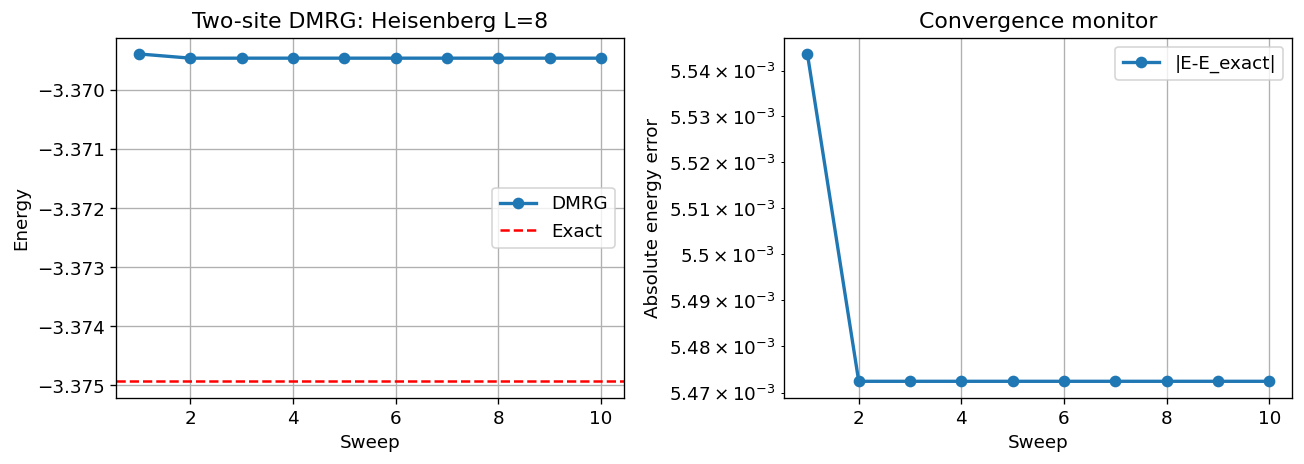

In [12]:
# Cell 12
# ----------------------------
# Heisenberg L=8 run
# ----------------------------
Lh = 8
Dmax_h = 16
nsweeps_h = 10

mpo_h, meta_h = build_heisenberg_mpo(Lh, J=1.0, h=0.0)
Hh = build_full_heisenberg_hamiltonian(Lh, J=1.0, h=0.0)
E_exact_h = exact_ground_state_energy(Hh)

psi0_h = random_mps(L=Lh, d=meta_h["d"], Dmax=6, seed=111, normalize=True)

psi_h, hist_h = run_two_site_dmrg(
    mpo_h, meta_h, psi0_h,
    Dmax=Dmax_h,
    nsweeps=nsweeps_h,
    eps_rel=1e-12,
    lanczos_tol=1e-10,
    H_full=Hh,
    label="Heisenberg L=8"
)

print("Heisenberg L=8 final energy =", hist_h["energy"][-1])
print("Heisenberg L=8 exact energy =", E_exact_h)
print("Absolute error =", abs(hist_h["energy"][-1] - E_exact_h))
print("Variance =", compute_variance_mpo(psi_h, mpo_h))

plot_dmrg_history(
    hist_h,
    exact_energy=E_exact_h,
    title="Two-site DMRG: Heisenberg L=8",
    filename="two_site_heisenberg_L8.png"
)

[AKLT L=8] sweep  1: E = -4.664433249649, bond_last = -4.664433249649, max_disc = 5.935e-07
[AKLT L=8] sweep  2: E = -4.664165271580, bond_last = -4.664165271580, max_disc = 5.935e-07
[AKLT L=8] sweep  3: E = -4.664452231101, bond_last = -4.664452231102, max_disc = 5.839e-07
[AKLT L=8] sweep  4: E = -4.664424360753, bond_last = -4.664424360753, max_disc = 5.839e-07
[AKLT L=8] sweep  5: E = -4.664376554023, bond_last = -4.664376554023, max_disc = 5.992e-07
[AKLT L=8] sweep  6: E = -4.664748495265, bond_last = -4.664748495265, max_disc = 8.968e-07
[AKLT L=8] sweep  7: E = -4.663979125599, bond_last = -4.663979125599, max_disc = 8.968e-07
[AKLT L=8] sweep  8: E = -4.664371481049, bond_last = -4.664371481049, max_disc = 6.690e-07
AKLT L=8 final energy = -4.66437148104906
AKLT L=8 exact energy = -4.666666666666655
AKLT L=8 formula energy = -4.666666666666666
Absolute error = 0.00229518561759523
Variance = 0.004838113933843147
Saved figure to: figureAKLT\two_site_aklt_L8.png


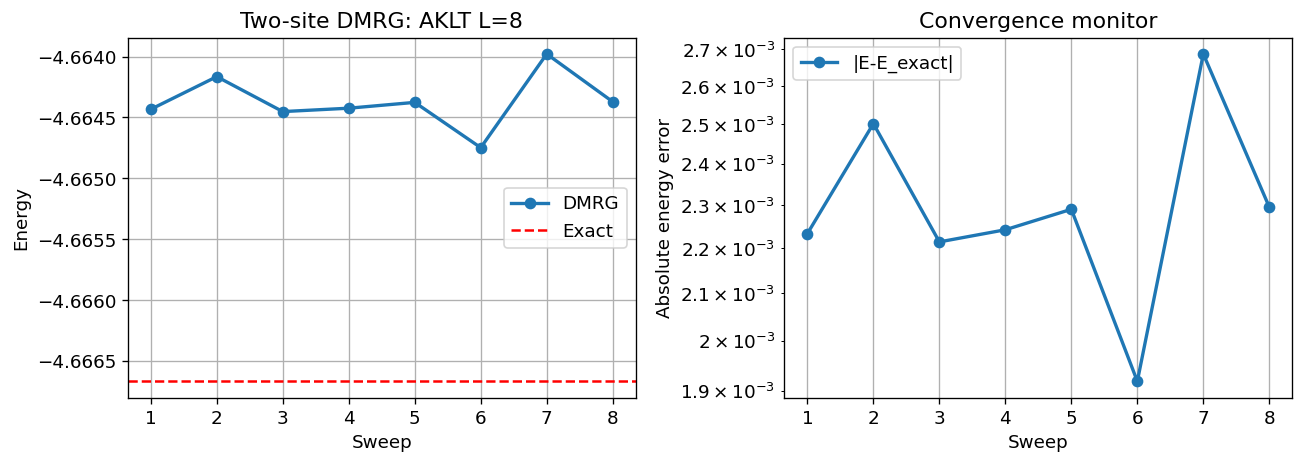

In [13]:
# Cell 13
# ----------------------------
# AKLT L=8 run
# ----------------------------
La = 8
Dmax_a = 12
nsweeps_a = 8

mpo_a, meta_a = build_aklt_mpo_generic(La)
Ha = build_full_aklt_hamiltonian(La)
E_exact_a = exact_ground_state_energy(Ha)
E_formula_a = -(La - 1) * (2.0 / 3.0)

psi0_a = random_mps(L=La, d=meta_a["d"], Dmax=6, seed=222, normalize=True)

psi_a, hist_a = run_two_site_dmrg(
    mpo_a, meta_a, psi0_a,
    Dmax=Dmax_a,
    nsweeps=nsweeps_a,
    eps_rel=1e-12,
    lanczos_tol=1e-10,
    H_full=Ha,
    label="AKLT L=8"
)

print("AKLT L=8 final energy =", hist_a["energy"][-1])
print("AKLT L=8 exact energy =", E_exact_a)
print("AKLT L=8 formula energy =", E_formula_a)
print("Absolute error =", abs(hist_a["energy"][-1] - E_exact_a))
print("Variance =", compute_variance_mpo(psi_a, mpo_a))

plot_dmrg_history(
    hist_a,
    exact_energy=E_exact_a,
    title="Two-site DMRG: AKLT L=8",
    filename="two_site_aklt_L8.png"
)

[Heisenberg L=10] sweep  1: E = -4.147897375038, bond_last = -4.147897375038, max_disc = 1.905e-11
[Heisenberg L=10] sweep  2: E = -4.231502363543, bond_last = -4.231502363543, max_disc = 1.905e-11
[Heisenberg L=10] sweep  3: E = -4.249865716812, bond_last = -4.249865716812, max_disc = 1.905e-11
[Heisenberg L=10] sweep  4: E = -4.249011215569, bond_last = -4.249011215569, max_disc = 1.905e-11
[Heisenberg L=10] sweep  5: E = -4.250216180819, bond_last = -4.250216180819, max_disc = 1.905e-11
[Heisenberg L=10] sweep  6: E = -4.250353467409, bond_last = -4.250353467409, max_disc = 1.905e-11
[Heisenberg L=10] sweep  7: E = -4.250337187701, bond_last = -4.250337187701, max_disc = 1.905e-11
[Heisenberg L=10] sweep  8: E = -4.250370854070, bond_last = -4.250370854070, max_disc = 1.905e-11
[Heisenberg L=10] sweep  9: E = -4.250338439404, bond_last = -4.250338439404, max_disc = 1.905e-11
[Heisenberg L=10] sweep 10: E = -4.250372017124, bond_last = -4.250372017124, max_disc = 1.905e-11
[Heisenber

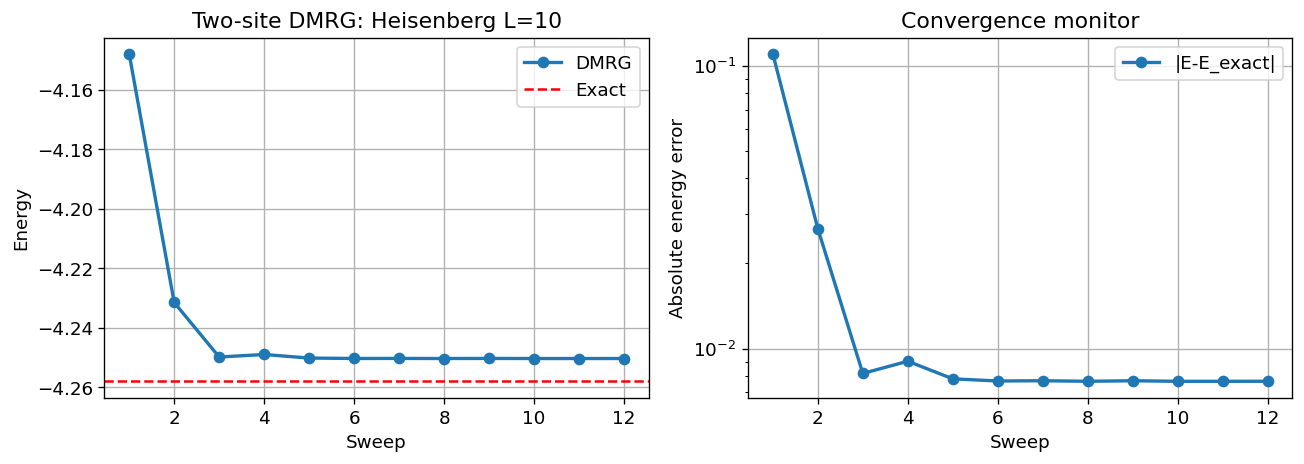


Exact AKLT MPS, L=10
  formula energy = -6.0
  mpo energy     = -6.0
  mpo variance   = 1.4210854715202004e-14
[AKLT L=10] sweep  1: E = -5.997992537196, bond_last = -5.997992537196, max_disc = 1.219e-06
[AKLT L=10] sweep  2: E = -5.997782128248, bond_last = -5.997782128248, max_disc = 5.793e-07
[AKLT L=10] sweep  3: E = -5.997606832815, bond_last = -5.997606832815, max_disc = 5.967e-07
[AKLT L=10] sweep  4: E = -5.997485619229, bond_last = -5.997485619229, max_disc = 5.967e-07
[AKLT L=10] sweep  5: E = -5.997547885062, bond_last = -5.997547885062, max_disc = 5.903e-07
[AKLT L=10] sweep  6: E = -5.997787474230, bond_last = -5.997787474230, max_disc = 5.864e-07
[AKLT L=10] sweep  7: E = -5.997658878834, bond_last = -5.997658878834, max_disc = 6.019e-07
[AKLT L=10] sweep  8: E = -5.997488764918, bond_last = -5.997488764918, max_disc = 6.019e-07
[AKLT L=10] sweep  9: E = -5.998287019026, bond_last = -5.998287019026, max_disc = 5.882e-07
[AKLT L=10] sweep 10: E = -5.997480476470, bond_las

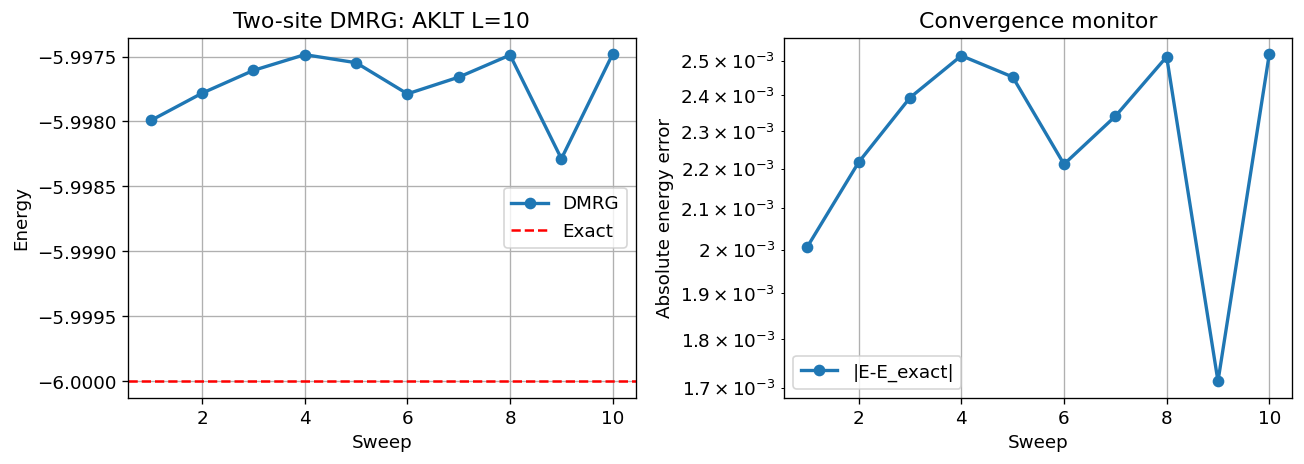

In [14]:
# Cell 14
# ----------------------------
# Heisenberg L=10 and AKLT L=10 runs
# ----------------------------
# Heisenberg L=10
Lh10 = 10
mpo_h10, meta_h10 = build_heisenberg_mpo(Lh10, J=1.0, h=0.0)
Hh10 = build_full_heisenberg_hamiltonian(Lh10, J=1.0, h=0.0)
E_exact_h10 = exact_ground_state_energy(Hh10)

psi0_h10 = random_mps(L=Lh10, d=meta_h10["d"], Dmax=8, seed=314, normalize=True)

psi_h10, hist_h10 = run_two_site_dmrg(
    mpo_h10, meta_h10, psi0_h10,
    Dmax=20,
    nsweeps=12,
    eps_rel=1e-12,
    lanczos_tol=1e-10,
    H_full=Hh10,
    label="Heisenberg L=10"
)

print("\nHeisenberg L=10")
print("  final energy =", hist_h10["energy"][-1])
print("  exact energy =", E_exact_h10)
print("  abs error    =", abs(hist_h10["energy"][-1] - E_exact_h10))
print("  variance     =", compute_variance_mpo(psi_h10, mpo_h10))

plot_dmrg_history(
    hist_h10,
    exact_energy=E_exact_h10,
    title="Two-site DMRG: Heisenberg L=10",
    filename="two_site_heisenberg_L10.png"
)

# AKLT L=10, no dense H
La10 = 10
mpo_a10, meta_a10 = build_aklt_mpo_generic(La10)
E_formula_a10 = -(La10 - 1) * (2.0 / 3.0)

psi_aklt_exact_10 = aklt_exact_mps_open(La10)
E_aklt_exact_mpo = normalized_mpo_energy(psi_aklt_exact_10, mpo_a10)
Var_aklt_exact_mpo = compute_variance_mpo(psi_aklt_exact_10, mpo_a10)

print("\nExact AKLT MPS, L=10")
print("  formula energy =", E_formula_a10)
print("  mpo energy     =", E_aklt_exact_mpo)
print("  mpo variance   =", Var_aklt_exact_mpo)

psi0_a10 = random_mps(L=La10, d=meta_a10["d"], Dmax=6, seed=2718, normalize=True)

psi_a10, hist_a10 = run_two_site_dmrg(
    mpo_a10, meta_a10, psi0_a10,
    Dmax=12,
    nsweeps=10,
    eps_rel=1e-12,
    lanczos_tol=1e-10,
    H_full=None,
    label="AKLT L=10"
)

E_a10 = normalized_mpo_energy(psi_a10, mpo_a10)
Var_a10 = compute_variance_mpo(psi_a10, mpo_a10)

print("\nAKLT L=10")
print("  final mpo energy =", E_a10)
print("  formula energy   =", E_formula_a10)
print("  abs error        =", abs(E_a10 - E_formula_a10))
print("  variance         =", Var_a10)

plot_dmrg_history(
    hist_a10,
    exact_energy=E_formula_a10,
    title="Two-site DMRG: AKLT L=10",
    filename="two_site_aklt_L10.png"
)

Saved figure to: figureAKLT\dmrg_error_comparison_L10.png


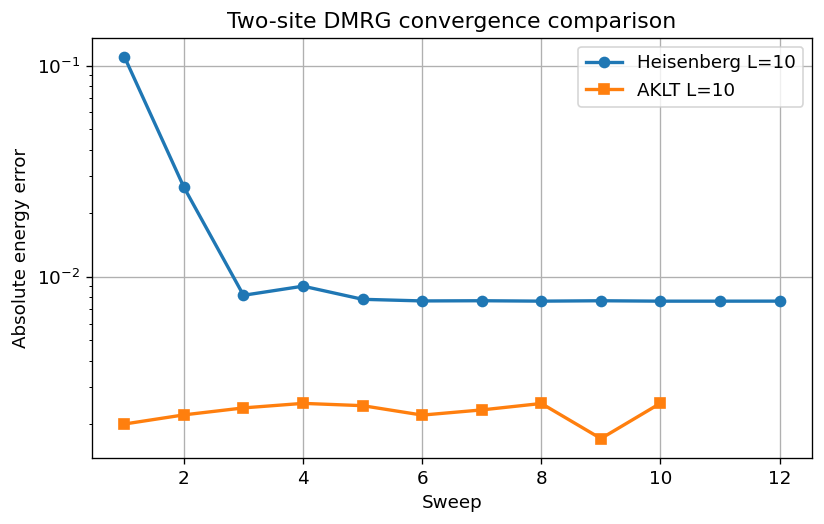

In [15]:
# Cell 15
# ----------------------------
# Convergence comparison figure
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(np.arange(1, len(hist_h10["energy"]) + 1),
            np.maximum(np.abs(hist_h10["energy"] - E_exact_h10), 1e-16),
            'o-', lw=2, label='Heisenberg L=10')

ax.semilogy(np.arange(1, len(hist_a10["energy"]) + 1),
            np.maximum(np.abs(hist_a10["energy"] - E_formula_a10), 1e-16),
            's-', lw=2, label='AKLT L=10')

ax.set_xlabel("Sweep")
ax.set_ylabel("Absolute energy error")
ax.set_title("Two-site DMRG convergence comparison")
ax.legend()

plt.tight_layout()
savefig("dmrg_error_comparison_L10.png")
plt.show()

In [16]:
# Cell 16
# ----------------------------
# Memory-safe observables from statevector reshaping
# ----------------------------
def mps_to_normalized_tensor(mps):
    psi = mps_to_statevector(mps)
    psi = psi / np.sqrt(np.vdot(psi, psi))
    L = len(mps)
    d = mps[0].shape[1]
    return psi.reshape((d,) * L)

def one_site_expectation_values_from_tensor(mps, op):
    Psi = mps_to_normalized_tensor(mps)
    L = len(mps)
    vals = []

    for i in range(L):
        perm = [i] + [j for j in range(L) if j != i]
        Psi_i = np.transpose(Psi, perm).reshape(Psi.shape[0], -1)
        val = np.einsum('ar,ab,br->', Psi_i.conj(), op, Psi_i, optimize=True)
        vals.append(float(np.real_if_close(val)))

    return np.array(vals)

def two_site_expectation_values_from_tensor(mps, op2):
    Psi = mps_to_normalized_tensor(mps)
    L = len(mps)
    vals = []

    for i in range(L - 1):
        perm = [i, i + 1] + [j for j in range(L) if j not in (i, i + 1)]
        Psi_ij = np.transpose(Psi, perm)
        d1, d2 = Psi_ij.shape[:2]
        Psi_ij = Psi_ij.reshape(d1, d2, -1)
        val = np.einsum('abr,abxy,xyr->', Psi_ij.conj(), op2, Psi_ij, optimize=True)
        vals.append(float(np.real_if_close(val)))

    return np.array(vals)

def heisenberg_two_site_operator(J=1.0):
    I, Sp, Sm, Sz = spin_half_ops()
    h = 0.5 * J * np.kron(Sp, Sm) + 0.5 * J * np.kron(Sm, Sp) + J * np.kron(Sz, Sz)
    return h.reshape(2, 2, 2, 2)

def entanglement_entropy_profile(mps):
    psi = mps_to_statevector(mps)
    psi = psi / np.sqrt(np.vdot(psi, psi))
    L = len(mps)
    d = mps[0].shape[1]

    ent = []
    for cut in range(1, L):
        M = psi.reshape(d**cut, d**(L - cut))
        s = svd(M, compute_uv=False)
        p = np.abs(s)**2
        p = p[p > 1e-15]
        ent.append(float(np.real_if_close(-np.sum(p * np.log(p)))))
    return np.array(ent)

# Heisenberg L=10 observables
_, _, _, Sz_half = spin_half_ops()
mz_h10 = one_site_expectation_values_from_tensor(psi_h10, Sz_half)
bond_h10 = two_site_expectation_values_from_tensor(psi_h10, heisenberg_two_site_operator())
ent_h10 = entanglement_entropy_profile(psi_h10)

# AKLT L=10 observables
_, _, _, Sz_one = spin_one_ops()
mz_a10 = one_site_expectation_values_from_tensor(psi_a10, Sz_one)
bond_a10 = two_site_expectation_values_from_tensor(psi_a10, aklt_two_site_hamiltonian())
ent_a10 = entanglement_entropy_profile(psi_a10)

print("Observable arrays computed.")

Observable arrays computed.


Saved figure to: figureAKLT\local_magnetization_L10.png


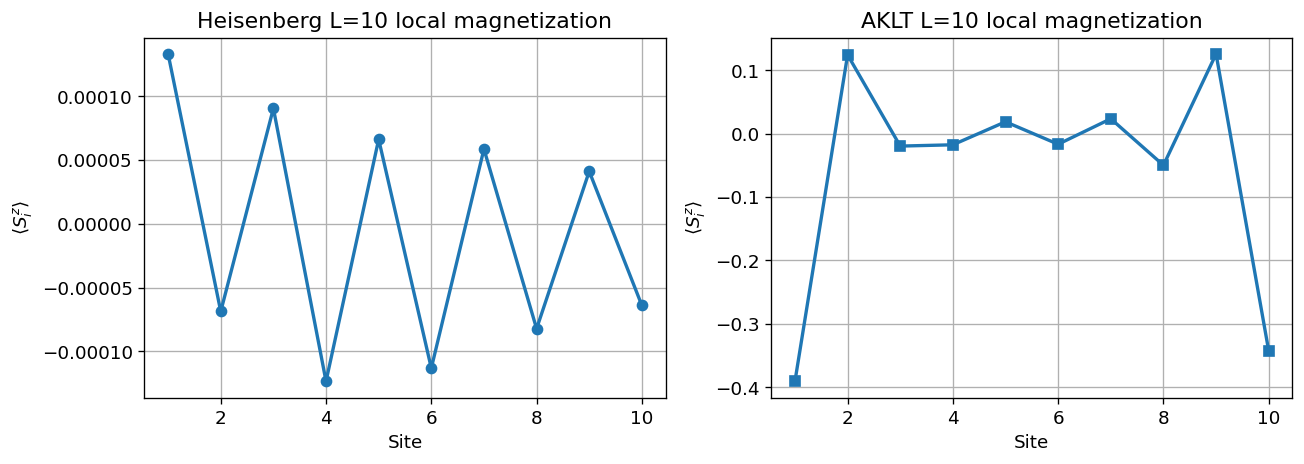

Saved figure to: figureAKLT\bond_energies_L10.png


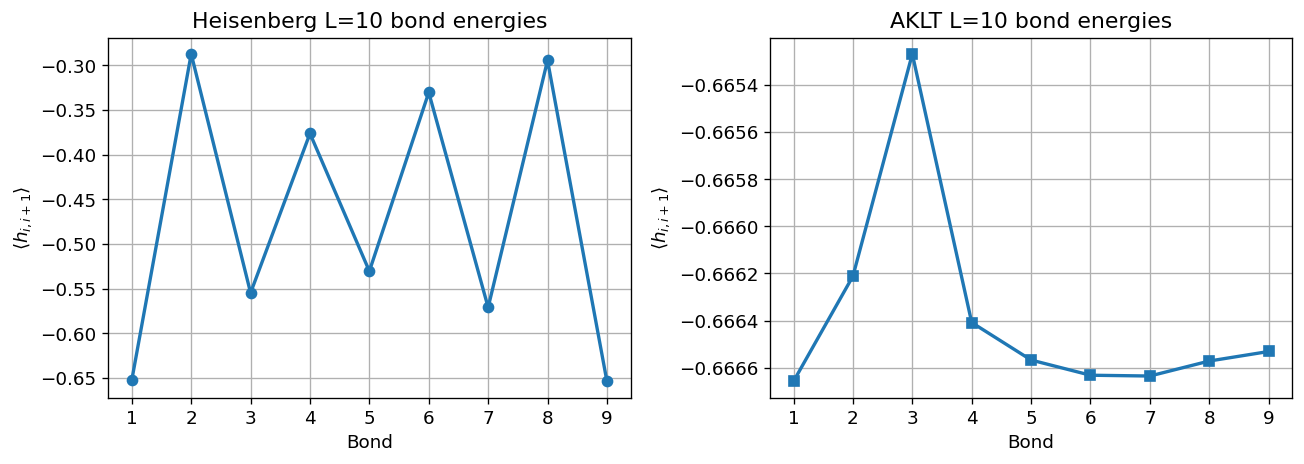

Saved figure to: figureAKLT\entanglement_entropy_L10.png


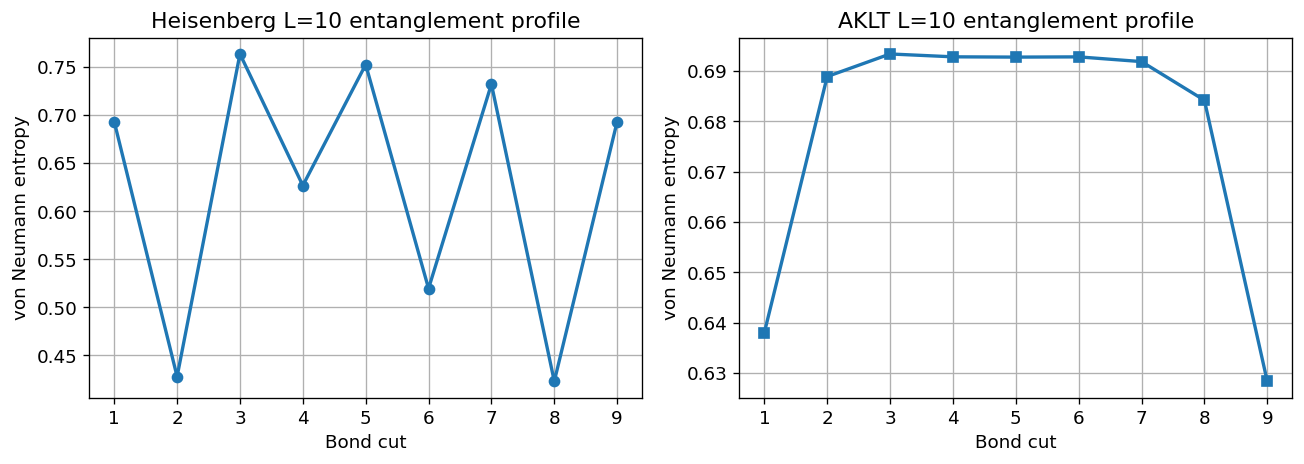

In [17]:
# Cell 17
# ----------------------------
# Observable figures
# ----------------------------
# Local magnetization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(mz_h10) + 1), mz_h10, 'o-', lw=2)
axes[0].set_title("Heisenberg L=10 local magnetization")
axes[0].set_xlabel("Site")
axes[0].set_ylabel(r"$\langle S_i^z\rangle$")

axes[1].plot(np.arange(1, len(mz_a10) + 1), mz_a10, 's-', lw=2)
axes[1].set_title("AKLT L=10 local magnetization")
axes[1].set_xlabel("Site")
axes[1].set_ylabel(r"$\langle S_i^z\rangle$")

plt.tight_layout()
savefig("local_magnetization_L10.png")
plt.show()

# Bond energies
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(bond_h10) + 1), bond_h10, 'o-', lw=2)
axes[0].set_title("Heisenberg L=10 bond energies")
axes[0].set_xlabel("Bond")
axes[0].set_ylabel(r"$\langle h_{i,i+1}\rangle$")

axes[1].plot(np.arange(1, len(bond_a10) + 1), bond_a10, 's-', lw=2)
axes[1].set_title("AKLT L=10 bond energies")
axes[1].set_xlabel("Bond")
axes[1].set_ylabel(r"$\langle h_{i,i+1}\rangle$")

plt.tight_layout()
savefig("bond_energies_L10.png")
plt.show()

# Entanglement entropy
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(ent_h10) + 1), ent_h10, 'o-', lw=2)
axes[0].set_title("Heisenberg L=10 entanglement profile")
axes[0].set_xlabel("Bond cut")
axes[0].set_ylabel("von Neumann entropy")

axes[1].plot(np.arange(1, len(ent_a10) + 1), ent_a10, 's-', lw=2)
axes[1].set_title("AKLT L=10 entanglement profile")
axes[1].set_xlabel("Bond cut")
axes[1].set_ylabel("von Neumann entropy")

plt.tight_layout()
savefig("entanglement_entropy_L10.png")
plt.show()